# **PRACTICAL 3: THEORY:**

# MINIMUM 3 HIDDEN LAYERS REQUIRED

1. INITIAL INFORMATION

2. COMPLEX MATHEMATICAL OPERATIONS

3. RELATIONSHIP BETWEEN NEURONS



VARNA TO WE CAN HAVE ONLY 1 HIDDEN LAYER ALSO, THAT IS ALSO A NN, BUT LIKE THE STANDARD IS THIS.


FOLLOWS SEQUENTIAL TOP DOWN APPROACH (OP OF 1ST LAYER IS THE INPUT OF THE 2ND LAYER AND SO ON...)

hence remember, 1st line to create nn:
model = Sequential()

VGG16:

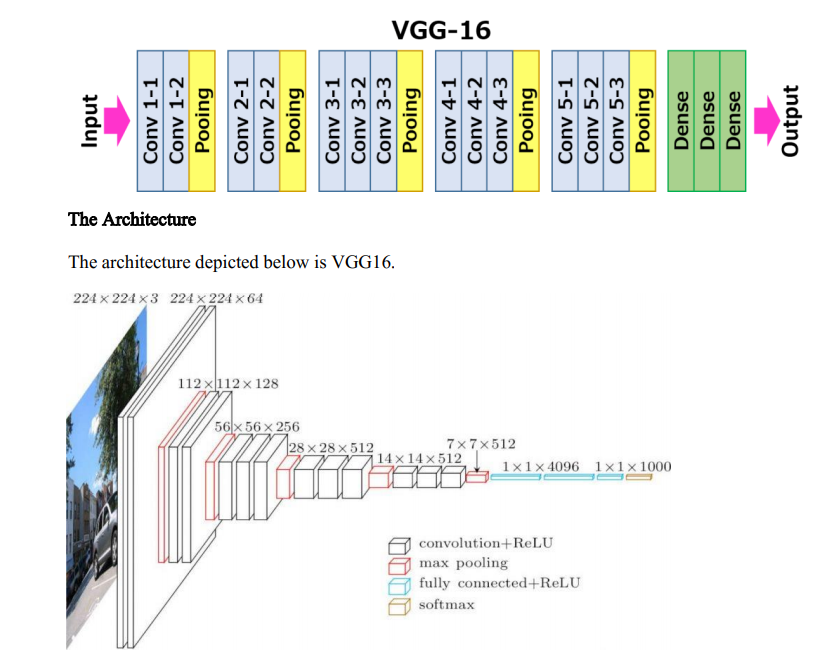



HERE 224 X 224 X 3 IS THE IMG SIZE

224 X 224 X 64 = HERE 64 MEANS THE IMG WILL PASS THROUGH 64 NEURONS

HERE BASICALLY WE KEEP ON DECREASING AND DOING...

HERE IT IS A 1 X 1 CONVOLUTION

AND THEN WE FINALLY GET THE OUTPUT


VGG16 USES 16 LAYERS, 1 INPUT 14 HIDDEN 1 OUTPUT

RESNET50:
ResNet50 is 50 layers deep (consisting of 48 convolutional layers, 1 MaxPool, and 1 AveragePool). It was originally designed to process standard image sizes of 224 × 224 pixels

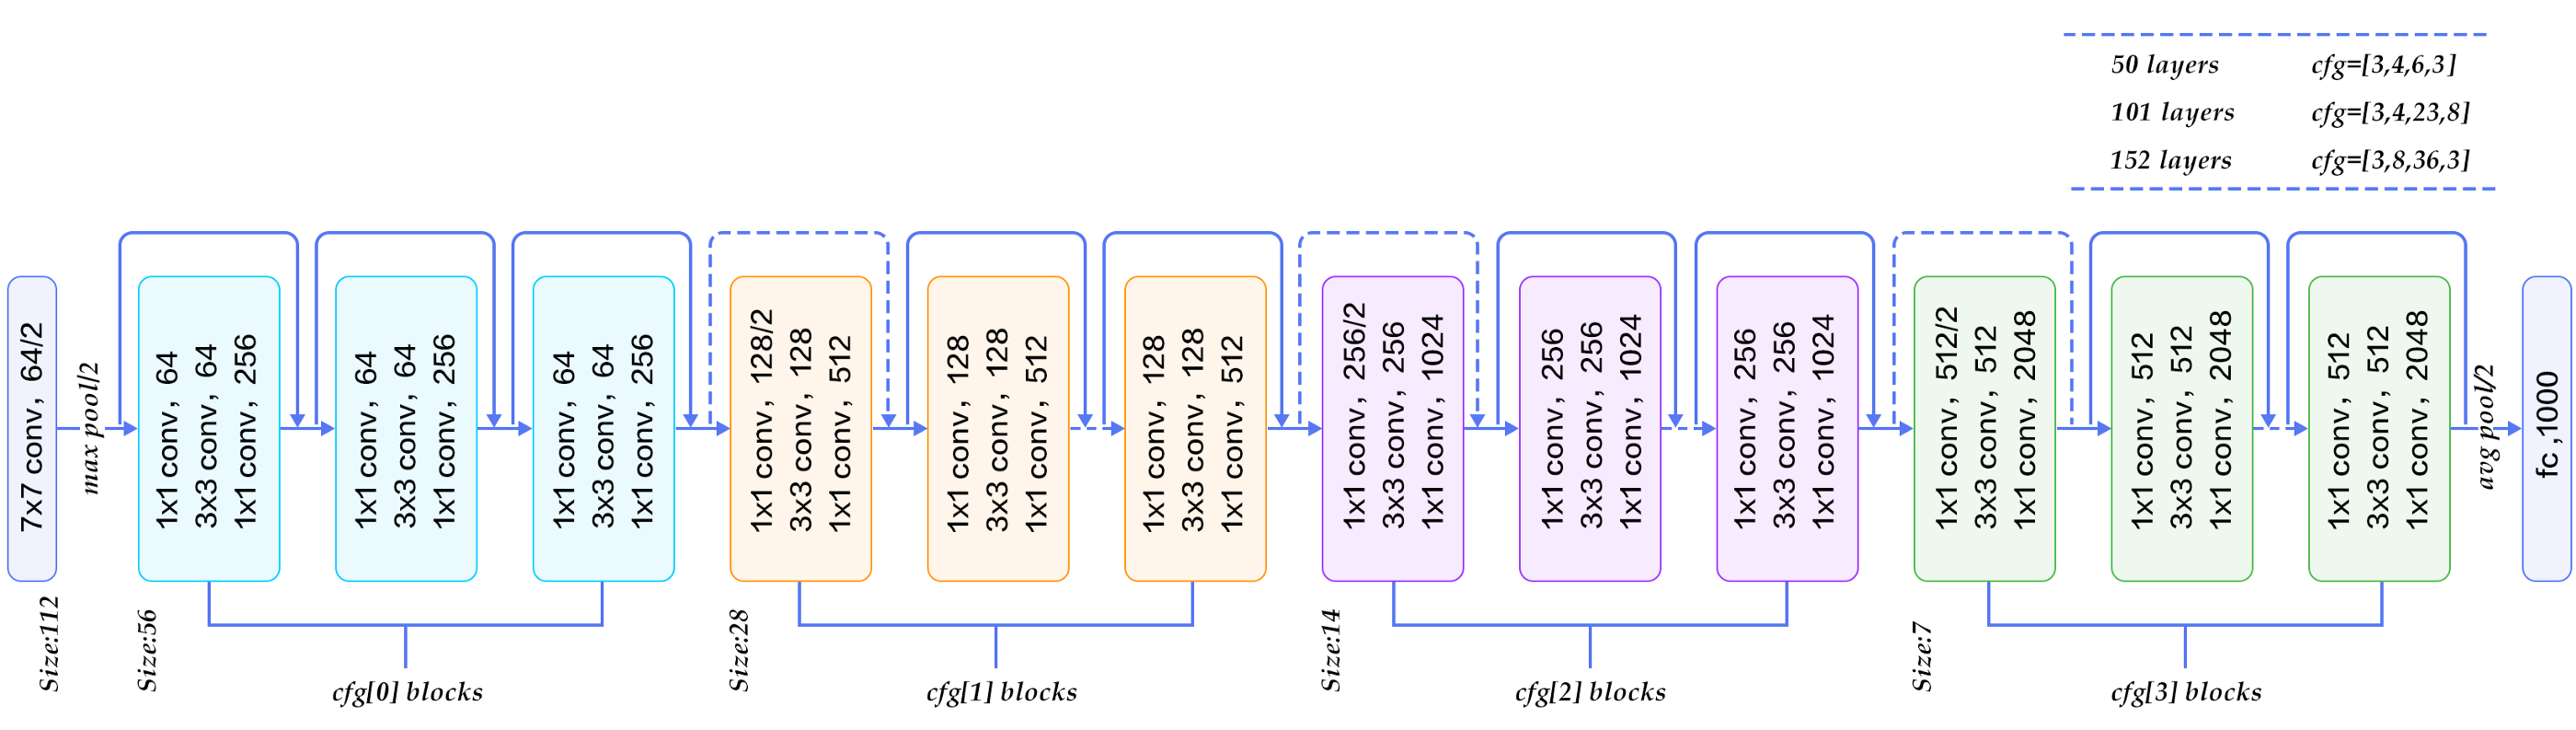

# **PRACTICAL 3:**

**AIM:**  Regularization Techniques for Deep Learning. Problem Statement: Implement L1/L2
Regularization and Dropout to reduce overfitting in Housing Price Prediction. Activities:
Train baseline model; Apply L1/L2 regularization; Compare performance with Dropout.

In [7]:
# ==============================
# HOUSING PRICE PREDICTION USING
# DEEP FEED FORWARD NEURAL NETWORK
# BY SHLOK VIJ 23070521143
# ==============================

# ---------- STEP 1 : Import Required Libraries ----------

import pandas as pd                  # Used to read and manipulate the dataset
import numpy as np                   # Used for numerical operations

# Used to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Used to standardize (normalize) the features
from sklearn.preprocessing import StandardScaler

# Used later to calculate performance metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# TensorFlow libraries for building the Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Used for L1 and L2 Regularization
from tensorflow.keras.regularizers import l1, l2

# Used to plot graphs
import matplotlib.pyplot as plt


# ---------- STEP 2 : Load the Dataset ----------

# Read the Kaggle House Prices dataset
data = pd.read_csv("train.csv")

# Display first 5 rows
print("Shlok Vij 23070521143\n")
print(data.head())


# ---------- STEP 3 : Data Preprocessing ----------

# Keep only numerical columns.
# Neural Networks cannot directly process text (categorical values)
data = data.select_dtypes(include=np.number)

# Check how many missing values are present
print(data.isnull().sum())


# Replace missing values with the mean of that column.
# Example:
# If values are 20, 30, NaN, 40
# Mean = 30
# NaN becomes 30.
data = data.fillna(data.mean())


# Check if missing values still exist
print(data.isnull().sum())


# ---------- STEP 4 : Define Features and Target ----------

# X contains all independent variables (input features)
X = data.drop("SalePrice", axis=1)

# y contains the dependent variable
# This is what the Neural Network has to predict.
y = data["SalePrice"]


print("\nShape of X :", X.shape)
print("Shape of y :", y.shape)


# ---------- STEP 5 : Train-Test Split ----------

# Split dataset into:
# 80% -> Training
# 20% -> Testing

# Why test_size = 0.2 ?
# It means 20% of the data is kept aside for testing.
# 80% is enough for learning while 20% is enough for evaluation.

# random_state = 42
# Keeps the split same every time the program runs.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


# ---------- STEP 6 : Feature Scaling ----------

# StandardScaler converts every feature to roughly:
# Mean = 0
# Standard Deviation = 1

# Neural Networks learn much faster when all features
# are on a similar scale.

scaler = StandardScaler()

# Learn mean and standard deviation from training data
X_train = scaler.fit_transform(X_train)

# Apply the same scaling on testing data
X_test = scaler.transform(X_test)

print("\nData preprocessing completed successfully!")

Shlok Vij 23070521143

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice 

In [4]:
# ======================================================
# STEP 7 : Create a Function to Build Neural Network
# ======================================================

# Instead of writing the same code 4 times,
# we create one function that builds a model.
# We can simply change the regularization or
# dropout settings whenever required.

def create_model(regularizer=None, use_dropout=False):

    # Create an empty Sequential Neural Network
    model = Sequential()

    # --------------------------------------------------
    # Hidden Layer 1
    # --------------------------------------------------
    model.add(Dense(
        units=64,                     # 64 neurons
        activation='relu',            # ReLU activation function
        kernel_regularizer=regularizer,   # L1/L2 Regularization (if given)
        input_shape=(X_train.shape[1],)   # Number of input features
    ))

    # Add Dropout only if required
    if use_dropout:
        model.add(Dropout(0.3))

    # --------------------------------------------------
    # Hidden Layer 2
    # --------------------------------------------------
    model.add(Dense(
        units=32,                     # 32 neurons
        activation='relu',
        kernel_regularizer=regularizer
    ))

    if use_dropout:
        model.add(Dropout(0.3))

    # --------------------------------------------------
    # Hidden Layer 3
    # --------------------------------------------------
    model.add(Dense(
        units=16,                     # 16 neurons
        activation='relu',
        kernel_regularizer=regularizer
    ))

    # --------------------------------------------------
    # Output Layer
    # --------------------------------------------------
    # Only 1 neuron because we are predicting
    # a single value (House Price)

    model.add(Dense(1))

    # --------------------------------------------------
    # Compile the Model
    # --------------------------------------------------

    model.compile(
        optimizer='adam',     # Adam optimizer updates weights efficiently
        loss='mse',           # Mean Squared Error for regression
        metrics=['mae']       # Also display Mean Absolute Error
    )

    return model


# ======================================================
# STEP 8 : Create Different Models
# ======================================================

# 1. Basic Deep Feed Forward Neural Network
baseline_model = create_model()

# 2. Neural Network with L1 Regularization
# L1 removes unnecessary weights and helps reduce overfitting.

l1_model = create_model(
    regularizer=l1(0.001)
)

# 3. Neural Network with L2 Regularization
# L2 makes weights smaller instead of removing them completely.

l2_model = create_model(
    regularizer=l2(0.001)
)

# 4. Neural Network with Dropout
# Dropout randomly switches OFF 30% neurons
# during training to reduce overfitting.

dropout_model = create_model(
    use_dropout=True
)


# ======================================================
# Display Model Summary
# ======================================================

print("\nBaseline Model")
baseline_model.summary()

print("\nL1 Model")
l1_model.summary()

print("\nL2 Model")
l2_model.summary()

print("\nDropout Model")
dropout_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Baseline Model


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

...

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)


Training Baseline Model...
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 39146262528.0000 - mae: 181524.7031 - val_loss: 37840375808.0000 - val_mae: 181097.6250
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 39142359040.0000 - mae: 181515.6094 - val_loss: 37833211904.0000 - val_mae: 181080.6094
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39127851008.0000 - mae: 181482.8281 - val_loss: 37808963584.0000 - val_mae: 181025.8438
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39083454464.0000 - mae: 181385.7344 - val_loss: 37740310528.0000 - val_mae: 180876.9688
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38969483264.0000 - mae: 181144.2969 - val_loss: 37585928192.0000 - val_mae: 180548.3125
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 38723801088.0000 - mae: 180642.1094 - val_loss: 37274976256.0000 - val_mae: 179896.6562
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38279184384.0000 - mae: 179713.2344 


WITH DROPOUT vs WITHOUT DROPOUT
                     Without Dropout      With Dropout
Training MAE            60134.183594        64280.843750
Validation MAE          57360.210938        60482.015625
Training Loss     64063532032.000000   83220796416.000000
Validation Loss   53016073728.000000   64728027136.000000


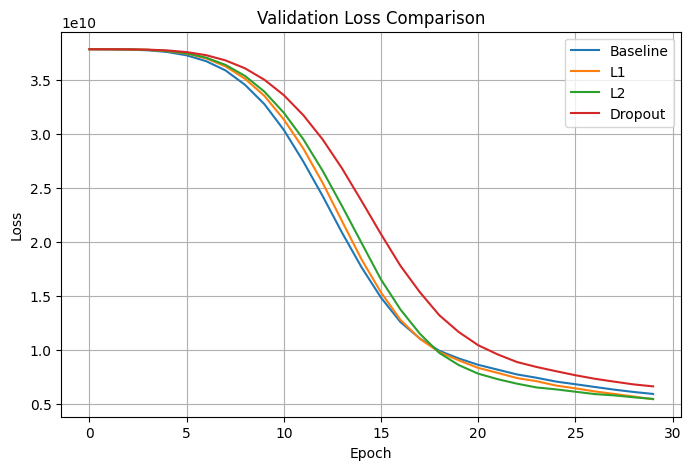

In [5]:
# ======================================================
# STEP 9 : Train All Models
# ======================================================

# Store all models in a dictionary.
# This allows us to train each model using a loop
# instead of writing the same code four times.

models = {
    "Baseline": baseline_model,
    "L1": l1_model,
    "L2": l2_model,
    "Dropout": dropout_model
}

# Dictionary to store training history
histories = {}

# Dictionary to store evaluation results
results = {}

# Train every model
for name, model in models.items():

    print(f"\nTraining {name} Model...")

    # Train the model
    history = model.fit(

        X_train,
        y_train,

        epochs=30,            # Train the model 30 times on the dataset
        batch_size=32,        # Use 32 samples in one batch
        validation_split=0.2,# 20% of training data used for validation
        verbose=1            # Display training progress

    )

    # Save training history for graph plotting
    histories[name] = history


# ======================================================
# STEP 10 : Test and Evaluate Models
# ======================================================

for name, model in models.items():

    # Predict house prices for test data
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    # Store results
    results[name] = [mse, rmse, mae, r2]


# ======================================================
# STEP 11 : Display Comparison Table
# ======================================================

comparison = pd.DataFrame(

    results,

    index=[
        "MSE",
        "RMSE",
        "MAE",
        "R2 Score"
    ]

).T

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)


# ======================================================
# STEP 11A : Compare Performance with Dropout
# ======================================================

dropout_comparison = pd.DataFrame({
    "Without Dropout": [
        histories["Baseline"].history["mae"][-1],
        histories["Baseline"].history["val_mae"][-1],
        histories["Baseline"].history["loss"][-1],
        histories["Baseline"].history["val_loss"][-1]
    ],
    "With Dropout": [
        histories["Dropout"].history["mae"][-1],
        histories["Dropout"].history["val_mae"][-1],
        histories["Dropout"].history["loss"][-1],
        histories["Dropout"].history["val_loss"][-1]
    ]
},
index=[
    "Training MAE",
    "Validation MAE",
    "Training Loss",
    "Validation Loss"
])

print("\n==============================")
print("WITH DROPOUT vs WITHOUT DROPOUT")
print("==============================")
print(dropout_comparison)

# ======================================================
# STEP 12 : Plot Validation Loss Graph
# ======================================================

plt.figure(figsize=(8,5))

for name in histories:

    plt.plot(

        histories[name].history["val_loss"],

        label=name

    )

plt.title("Validation Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()